### Model Training and Evaluation

This notebook trains and compares supervised machine learning models on the simulated imaging-derived feature dataset.

The goal is not clinical prediction. The goal is to demonstrate a reproducible research-style ML workflow using lesion-style ROI features, ALFF-style features, and connectivity-style features.

In [1]:
import sys
import os
from pathlib import Path

# Change working directory to project root if running from notebooks directory
if Path.cwd().name == "notebooks":
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path(".").resolve()))

from src.train_models import load_dataset, evaluate_models

### Load dataset

In [2]:
X, y, feature_names = load_dataset("data/simulated_pte_features.csv")

print("Feature matrix shape:", X.shape)
print("Label distribution:")
print(y.value_counts())

X.head()

Feature matrix shape: (300, 15)
Label distribution:
label
1    150
0    150
Name: count, dtype: int64


,right_temporal_lesion_volume,left_temporal_lesion_volume,right_occipital_lesion_volume,left_occipital_lesion_volume,cerebellum_lesion_volume,right_parietal_lesion_volume,right_temporal_alff,left_temporal_alff,right_occipital_alff,left_occipital_alff,right_parietal_alff,temporal_occipital_connectivity,temporal_cerebellum_connectivity,frontal_temporal_connectivity,parietal_occipital_connectivity
0,2.325100,1.642120,1.064650,1.332123,1.631803,1.086499,0.707887,0.547716,0.554608,0.455691,0.534352,0.468461,0.466343,0.089005,0.421831
1,1.932099,2.042947,1.981678,1.616930,1.641002,1.322292,0.492168,0.624073,0.570617,0.821878,0.548757,0.342300,0.324315,0.084700,0.482010
2,1.474412,1.726660,2.441934,2.305522,1.058055,1.234558,0.289301,0.561662,0.538511,0.714483,0.632756,0.600288,0.415233,0.101735,0.350111
3,1.389896,1.329794,0.839342,0.440637,1.074011,1.110093,0.623060,0.410351,0.542470,0.422835,0.503427,0.363988,0.289504,0.322324,0.340319
4,2.021485,1.616672,1.740089,0.931080,1.882120,0.953125,0.771142,0.642699,0.438485,0.640629,0.391932,0.265181,0.512627,0.336772,0.312613


### Feature groups

In [3]:
lesion_features = [col for col in X.columns if "lesion_volume" in col]
alff_features = [col for col in X.columns if "alff" in col]
connectivity_features = [col for col in X.columns if "connectivity" in col]

print("Lesion-style features:", len(lesion_features))
print("ALFF-style features:", len(alff_features))
print("Connectivity-style features:", len(connectivity_features))

Lesion-style features: 6
ALFF-style features: 5
Connectivity-style features: 4


### Train and evaluate models

In [5]:
results_df, best_model_name = evaluate_models(
    X,
    y,
    output_dir="outputs"
)

results_df

,model,test_auc,accuracy,precision,recall,f1_score,cv_auc_mean,cv_auc_std
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0,0.0
1,Linear SVM,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,RBF Kernel SVM,1.0,1.0,1.0,1.0,1.0,1.0,0.0
3,Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,0.0
4,MLP Classifier,1.0,1.0,1.0,1.0,1.0,1.0,0.0


<Figure size 700x600 with 0 Axes>

<Figure size 600x500 with 0 Axes>

### Display best model

In [6]:
print("Best model:", best_model_name)

Best model: Logistic Regression


### Load model comparison file

In [7]:
comparison = pd.read_csv("outputs/model_comparison.csv")
comparison

,model,test_auc,accuracy,precision,recall,f1_score,cv_auc_mean,cv_auc_std
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0,0.0
1,Linear SVM,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,RBF Kernel SVM,1.0,1.0,1.0,1.0,1.0,1.0,0.0
3,Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,0.0
4,MLP Classifier,1.0,1.0,1.0,1.0,1.0,1.0,0.0


### Simple bar chart of AUC

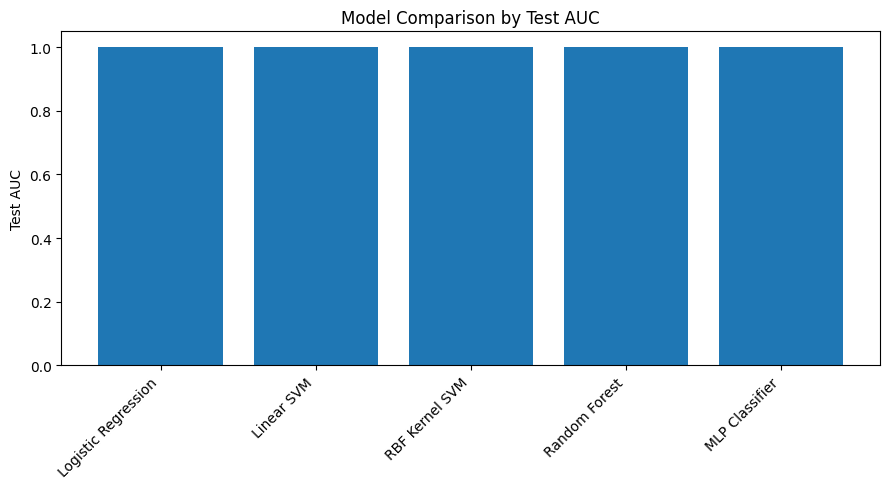

In [8]:
plt.figure(figsize=(9, 5))
plt.bar(comparison["model"], comparison["test_auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test AUC")
plt.title("Model Comparison by Test AUC")
plt.tight_layout()
plt.show()

### Markdown: Interpretation

The model comparison table summarizes how different classical machine learning models perform on the simulated imaging-derived feature dataset.

Because the dataset is simulated, the results should not be interpreted as clinical findings. Instead, this experiment demonstrates the ability to build a reproducible supervised ML workflow with train/test splitting, cross-validation, model comparison, metric reporting, and saved model artifacts.